# Toy recurrent Wong-Wang + DMC demo

This notebook is a teaching toy example. It is not a full implementation of the project model.

The goal is to show, with simple numbers, how a Wong-Wang recurrent competition layer can amplify an early DMC flanker advantage into a fast error.

In the full project, DMC first multiplies flanker and target evidence by time-varying multipliers. Here we skip that full machinery and directly provide a short evidence sequence.

In Wong-Wang competition, the recurrent term is:

```python
s @ J_matrix
```

where `s` is the current state and `J_matrix` is the recurrent matrix. Positive diagonal entries represent self-excitation. Negative off-diagonal entries represent lateral inhibition.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

## Toy recurrent Wong-Wang simulator

At each time step, the model combines the external evidence with the recurrent input from the previous state. The state is then updated by a small fraction of that total drive.

In [2]:
def simulate_toy_recurrent_ww(
    evidence_sequence,
    s0=None,
    threshold=0.30,
    update_rate=0.20,
    self_excitation=0.30,
    lateral_inhibition=-0.10,
    directions=("left", "right", "up", "down"),
):
    directions = tuple(directions)
    n_directions = len(directions)

    J = np.full((n_directions, n_directions), lateral_inhibition, dtype=float)
    np.fill_diagonal(J, self_excitation)

    evidence_array = np.asarray(evidence_sequence, dtype=float)
    if evidence_array.ndim != 2 or evidence_array.shape[1] != n_directions:
        raise ValueError(
            f"evidence_sequence must have shape (time, {n_directions}). "
            f"Got {evidence_array.shape}."
        )

    if s0 is None:
        s = np.zeros(n_directions, dtype=float)
    else:
        s = np.asarray(s0, dtype=float)
        if s.shape != (n_directions,):
            raise ValueError(f"s0 must have shape ({n_directions},). Got {s.shape}.")

    trace_rows = []
    trajectory_rows = [{"time": 0, **dict(zip(directions, s))}]
    decision = None

    for step, evidence_t in enumerate(evidence_array, start=1):
        s_before = s.copy()
        recurrent_input = s_before @ J
        total_drive = evidence_t + recurrent_input
        s_next = s_before + update_rate * total_drive

        if decision is None:
            crossed = np.flatnonzero(s_next >= threshold)
            if crossed.size:
                winner_index = crossed[np.argmax(s_next[crossed])]
                decision = {
                    "time_step": step,
                    "direction": directions[winner_index],
                    "state_value": float(s_next[winner_index]),
                    "threshold": threshold,
                }

        row = {"time_step": step}
        for label, values in [
            ("evidence", evidence_t),
            ("recurrent_input", recurrent_input),
            ("total_drive", total_drive),
            ("state_before", s_before),
            ("state_after", s_next),
        ]:
            for direction, value in zip(directions, values):
                row[f"{label}_{direction}"] = value
        trace_rows.append(row)

        s = s_next
        trajectory_rows.append({"time": step, **dict(zip(directions, s))})

    if decision is None:
        best_index = int(np.argmax(s))
        decision = {
            "time_step": None,
            "direction": None,
            "state_value": float(s[best_index]),
            "threshold": threshold,
        }

    trace_df = pd.DataFrame(trace_rows)
    trajectory = pd.DataFrame(trajectory_rows)
    J_df = pd.DataFrame(J, index=directions, columns=directions)

    return trace_df, trajectory, J_df, decision

## Example trial

- Target: `up`
- Flanker: `left`
- Early phase: flanker has the input advantage
- Late phase: target has the input advantage

The first three time steps use early evidence. The next four time steps use late evidence.

In [3]:
directions = ("left", "right", "up", "down")

target = "up"
flanker = "left"

early_evidence = np.array([0.50, 0.10, 0.35, 0.05])
late_evidence = np.array([0.20, 0.10, 0.55, 0.05])

evidence_sequence = np.vstack([
    np.tile(early_evidence, (3, 1)),
    np.tile(late_evidence, (4, 1)),
])

trace_df, trajectory, J, decision = simulate_toy_recurrent_ww(
    evidence_sequence,
    directions=directions,
)

## Recurrent matrix

In [4]:
J

,left,right,up,down
left,0.3,-0.1,-0.1,-0.1
right,-0.1,0.3,-0.1,-0.1
up,-0.1,-0.1,0.3,-0.1
down,-0.1,-0.1,-0.1,0.3


## Decision result

In [5]:
decision

{'time_step': 3,
 'direction': 'left',
 'state_value': 0.31232000000000004,
 'threshold': 0.3}

## Trace table

In [6]:
trace_df

,time_step,evidence_left,evidence_right,evidence_up,evidence_down,recurrent_input_left,recurrent_input_right,recurrent_input_up,recurrent_input_down,total_drive_left,...,total_drive_up,total_drive_down,state_before_left,state_before_right,state_before_up,state_before_down,state_after_left,state_after_right,state_after_up,state_after_down
0,1,0.5,0.1,0.35,0.05,0.000,0.000,0.000,0.000,0.500,...,0.350,0.050,0.000,0.000,0.000,0.000,0.100,0.020,0.070,0.010
1,2,0.5,0.1,0.35,0.05,0.020,-0.012,0.008,-0.016,0.520,...,0.358,0.034,0.100,0.020,0.070,0.010,0.204,0.038,0.142,0.017
2,3,0.5,0.1,0.35,0.05,0.042,-0.025,0.017,-0.033,0.542,...,0.367,0.017,0.204,0.038,0.142,0.017,0.312,0.053,0.215,0.020
3,4,0.2,0.1,0.55,0.05,0.065,-0.039,0.026,-0.052,0.265,...,0.576,-0.002,0.312,0.053,0.215,0.020,0.365,0.065,0.330,0.020
4,5,0.2,0.1,0.55,0.05,0.068,-0.052,0.054,-0.070,0.268,...,0.604,-0.020,0.365,0.065,0.330,0.020,0.419,0.074,0.451,0.016
5,6,0.2,0.1,0.55,0.05,0.072,-0.066,0.084,-0.090,0.272,...,0.634,-0.040,0.419,0.074,0.451,0.016,0.473,0.081,0.578,0.008
6,7,0.2,0.1,0.55,0.05,0.075,-0.082,0.117,-0.111,0.275,...,0.667,-0.061,0.473,0.081,0.578,0.008,0.528,0.085,0.711,-0.004


## State trajectory

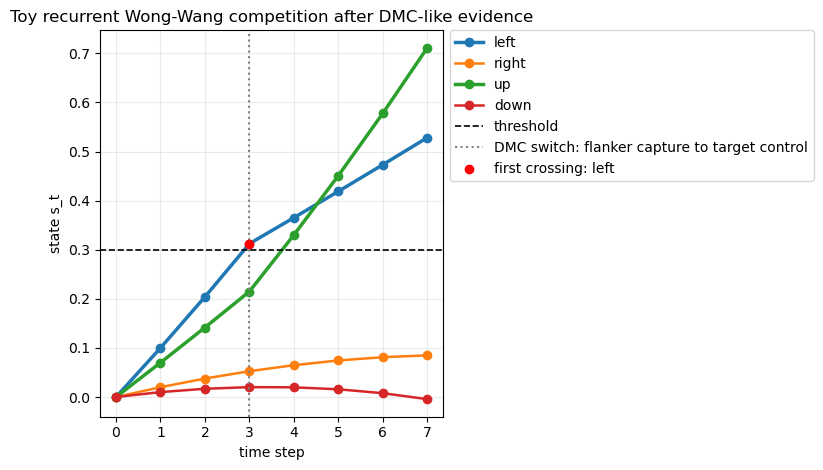

In [7]:
threshold = decision["threshold"]
phase_switch_time = 3

fig, ax = plt.subplots(figsize=(8, 4.8))

for direction in directions:
    linewidth = 2.5 if direction in {target, flanker} else 1.8
    ax.plot(
        trajectory["time"],
        trajectory[direction],
        marker="o",
        linewidth=linewidth,
        label=direction,
    )

ax.axhline(threshold, color="black", linestyle="--", linewidth=1.2, label="threshold")
ax.axvline(
    phase_switch_time,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="DMC switch: flanker capture to target control",
)

if decision["time_step"] is not None:
    ax.scatter(
        [decision["time_step"]],
        [decision["state_value"]],
        color="red",
        zorder=5,
        label=f"first crossing: {decision['direction']}",
    )

ax.set_title("Toy recurrent Wong-Wang competition after DMC-like evidence")
ax.set_xlabel("time step")
ax.set_ylabel("state s_t")
ax.set_xticks(trajectory["time"])
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Interpretation

DMC gives the flanker an early input advantage. In this toy trial, that means `left` starts ahead even though the true target is `up`.

Recurrent self-excitation then amplifies the direction that is already leading. At the same time, lateral inhibition suppresses the other directions.

If the flanker crosses the threshold before target control becomes strong enough, the model produces a fast error.

If the flanker does not cross the threshold early, the later target input can become dominant and produce a slower correct response.